### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [22]:
data = pd.read_csv('data/coupons.csv')

In [23]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [24]:
# Q2: Investigate missing / problematic data
print("Shape:", data.shape)

missing = data.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nColumns with missing values:")
print(pd.DataFrame({'n_missing': missing,
                    'pct_missing': (missing / len(data) * 100).round(2)}))

print("\nDuplicate rows:", data.duplicated().sum())

# The five 'frequency' columns are ordinal strings, not numbers.
for c in ['Bar','CoffeeHouse','CarryAway','RestaurantLessThan20','Restaurant20To50']:
    print(f"\n{c}: {sorted(data[c].dropna().unique().tolist())}")

Shape: (12684, 26)

Columns with missing values:
                      n_missing  pct_missing
car                       12576        99.15
CoffeeHouse                 217         1.71
Restaurant20To50            189         1.49
CarryAway                   151         1.19
RestaurantLessThan20        130         1.02
Bar                         107         0.84

Duplicate rows: 74

Bar: ['1~3', '4~8', 'gt8', 'less1', 'never']

CoffeeHouse: ['1~3', '4~8', 'gt8', 'less1', 'never']

CarryAway: ['1~3', '4~8', 'gt8', 'less1', 'never']

RestaurantLessThan20: ['1~3', '4~8', 'gt8', 'less1', 'never']

Restaurant20To50: ['1~3', '4~8', 'gt8', 'less1', 'never']


3. Decide what to do about your missing data -- drop, replace, other...

In [25]:
# Q3: Decide what to do about missing data
#
# 'car' is ~99% missing -> essentially no usable signal, so drop the column.
# The five frequency columns are 0.8-1.7% missing. They are ORDINAL CATEGORICALS
# ('never' < 'less1' < '1~3' < '4~8' < 'gt8'), so mean/median imputation is
# meaningless and mode imputation would invent habits the respondent never
# reported. Dropping those rows costs <5% of the data and keeps every remaining
# value truthful, so we drop.

data = data.drop(columns=['car'])

freq_cols = ['Bar', 'CoffeeHouse', 'CarryAway',
             'RestaurantLessThan20', 'Restaurant20To50']
data = data.dropna(subset=freq_cols)

data = data.drop_duplicates()

print("Shape after cleaning:", data.shape)
print("Total remaining missing values:", data.isna().sum().sum())

Shape after cleaning: (12007, 25)
Total remaining missing values: 0


4. What proportion of the total observations chose to accept the coupon?



In [26]:
# Q4: Proportion of total observations that accepted the coupon
accept_rate = data['Y'].mean()
print(f"Accepted: {data['Y'].sum():,} of {len(data):,} observations")
print(f"Proportion accepting the coupon: {accept_rate:.4f}  ({accept_rate*100:.2f}%)")

Accepted: 6,825 of 12,007 observations
Proportion accepting the coupon: 0.5684  (56.84%)


5. Use a bar plot to visualize the `coupon` column.

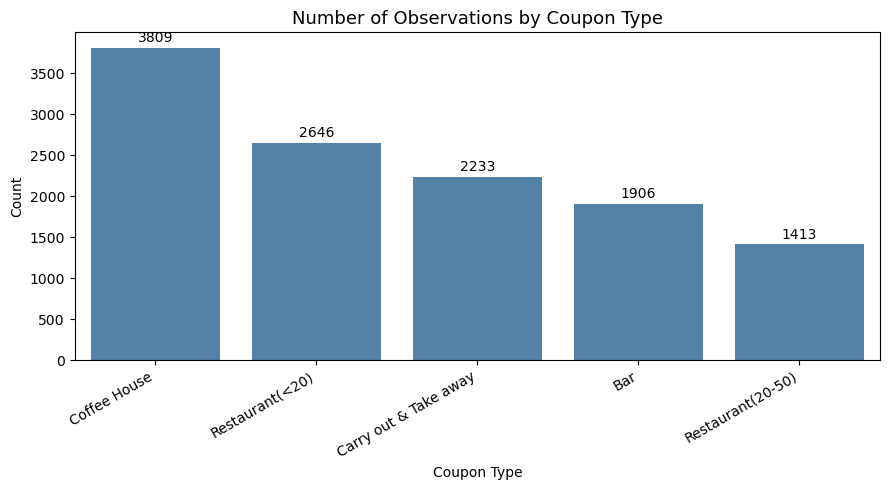

coupon
Coffee House             3809
Restaurant(<20)          2646
Carry out & Take away    2233
Bar                      1906
Restaurant(20-50)        1413
Name: count, dtype: int64


In [27]:
# Q5: Bar plot of the coupon column
plt.figure(figsize=(9, 5))
order = data['coupon'].value_counts().index
ax = sns.countplot(data=data, x='coupon', order=order, color='steelblue')
ax.set_title('Number of Observations by Coupon Type', fontsize=13)
ax.set_xlabel('Coupon Type')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
ax.bar_label(ax.containers[0], fmt='%d', padding=2)
plt.tight_layout()
plt.show()

print(data['coupon'].value_counts())

6. Use a histogram to visualize the temperature column.

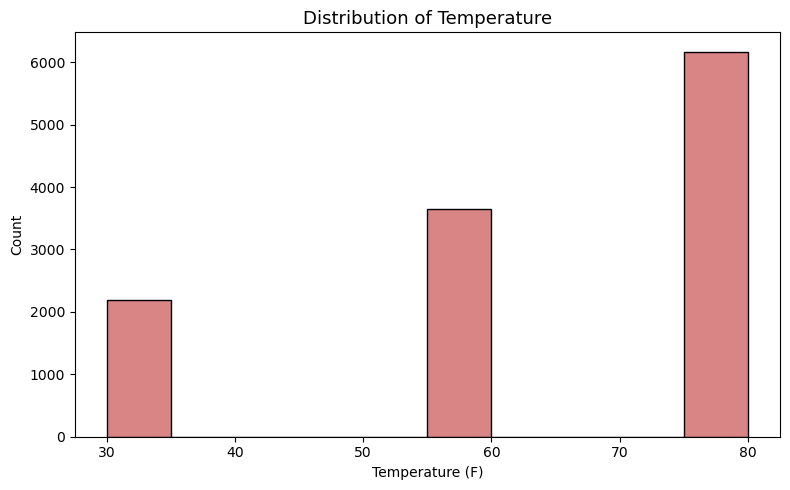

temperature
30    2184
55    3652
80    6171
Name: count, dtype: int64


In [28]:
# Q6: Histogram of the temperature column
plt.figure(figsize=(8, 5))
ax = sns.histplot(data=data, x='temperature', bins=10, color='indianred')
ax.set_title('Distribution of Temperature', fontsize=13)
ax.set_xlabel('Temperature (F)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# NOTE: temperature only takes three distinct values, so this "histogram"
# renders as three bars. The column is effectively categorical.
print(data['temperature'].value_counts().sort_index())

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [29]:
# Bar Q1: DataFrame of just the bar coupons
bar_coupons = data[data['coupon'] == 'Bar'].copy()
print("Bar coupon observations:", bar_coupons.shape)
bar_coupons.head()

Bar coupon observations: (1906, 25)


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,1,0,1,1
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,0,1,0
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,1,0,0


2. What proportion of bar coupons were accepted?


In [30]:
# Bar Q2: Proportion of bar coupons accepted
bar_rate = bar_coupons['Y'].mean()
print(f"Bar coupon acceptance:  {bar_rate:.4f}  ({bar_rate*100:.2f}%)")
print(f"All-coupon acceptance:  {data['Y'].mean()*100:.2f}%")
print(f"Bar coupons underperform by {(data['Y'].mean()-bar_rate)*100:.2f} pp")

Bar coupon acceptance:  0.4119  (41.19%)
All-coupon acceptance:  56.84%
Bar coupons underperform by 15.66 pp


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [31]:
# Bar Q3: 3 or fewer bar visits per month vs. more than 3
three_or_fewer  = ['never', 'less1', '1~3']
more_than_three = ['4~8', 'gt8']

grp_le3 = bar_coupons[bar_coupons['Bar'].isin(three_or_fewer)]
grp_gt3 = bar_coupons[bar_coupons['Bar'].isin(more_than_three)]

print(f"3 or fewer visits/month:  {grp_le3['Y'].mean()*100:.2f}%   (n={len(grp_le3)})")
print(f"More than 3 visits/month: {grp_gt3['Y'].mean()*100:.2f}%   (n={len(grp_gt3)})")
print(f"\nDifference: {(grp_gt3['Y'].mean()-grp_le3['Y'].mean())*100:.2f} percentage points")

3 or fewer visits/month:  37.24%   (n=1713)
More than 3 visits/month: 76.17%   (n=193)

Difference: 38.92 percentage points


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [32]:
# Bar Q4: goes to a bar more than once a month AND over age 25
#
# JUDGMENT CALL: 'age' is a string column whose buckets are
# below21, 21, 26, 31, 36, 41, 46, 50plus. The '21' bucket spans ages 21-25,
# so "over the age of 25" is read here as EXCLUDING '21'.
more_than_once = ['1~3', '4~8', 'gt8']
over_25 = ['26', '31', '36', '41', '46', '50plus']

mask4 = bar_coupons['Bar'].isin(more_than_once) & bar_coupons['age'].isin(over_25)

print(f"Bar >1/month AND over 25: {bar_coupons[mask4]['Y'].mean()*100:.2f}%   (n={mask4.sum()})")
print(f"All others:               {bar_coupons[~mask4]['Y'].mean()*100:.2f}%   (n={(~mask4).sum()})")
print(f"\nDifference: {(bar_coupons[mask4]['Y'].mean()-bar_coupons[~mask4]['Y'].mean())*100:.2f} pp")

Bar >1/month AND over 25: 68.98%   (n=403)
All others:               33.73%   (n=1503)

Difference: 35.25 pp


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [33]:
# Bar Q5: bar >1/month, passengers not a kid, occupation not farming/fishing/forestry
mask5 = (bar_coupons['Bar'].isin(more_than_once)
         & (bar_coupons['passanger'] != 'Kid(s)')
         & (bar_coupons['occupation'] != 'Farming Fishing & Forestry'))

print(f"Target group: {bar_coupons[mask5]['Y'].mean()*100:.2f}%   (n={mask5.sum()})")
print(f"All others:   {bar_coupons[~mask5]['Y'].mean()*100:.2f}%   (n={(~mask5).sum()})")
print(f"\nDifference: {(bar_coupons[mask5]['Y'].mean()-bar_coupons[~mask5]['Y'].mean())*100:.2f} pp")

Target group: 70.94%   (n=530)
All others:   29.72%   (n=1376)

Difference: 41.22 pp


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [34]:
# Bar Q6: three conditions combined with OR
under_30         = ['below21', '21', '26']
cheap_gt4        = ['4~8', 'gt8']
income_under_50k = ['Less than $12500', '$12500 - $24999',
                    '$25000 - $37499', '$37500 - $49999']

cond1 = (bar_coupons['Bar'].isin(more_than_once)
         & (bar_coupons['passanger'] != 'Kid(s)')
         & (bar_coupons['maritalStatus'] != 'Widowed'))

cond2 = bar_coupons['Bar'].isin(more_than_once) & bar_coupons['age'].isin(under_30)

cond3 = (bar_coupons['RestaurantLessThan20'].isin(cheap_gt4)
         & bar_coupons['income'].isin(income_under_50k))

combined = cond1 | cond2 | cond3

print("Each condition on its own:")
print(f"  1) bar >1/mo, no kid passenger, not widowed : {bar_coupons[cond1]['Y'].mean()*100:.2f}%  (n={cond1.sum()})")
print(f"  2) bar >1/mo and under 30                   : {bar_coupons[cond2]['Y'].mean()*100:.2f}%  (n={cond2.sum()})")
print(f"  3) cheap restaurants >4/mo, income <50K     : {bar_coupons[cond3]['Y'].mean()*100:.2f}%  (n={cond3.sum()})")

print(f"\nCombined (OR): {bar_coupons[combined]['Y'].mean()*100:.2f}%   (n={combined.sum()})")
print(f"All others:    {bar_coupons[~combined]['Y'].mean()*100:.2f}%   (n={(~combined).sum()})")

Each condition on its own:
  1) bar >1/mo, no kid passenger, not widowed : 70.94%  (n=530)
  2) bar >1/mo and under 30                   : 71.95%  (n=328)
  3) cheap restaurants >4/mo, income <50K     : 45.65%  (n=333)

Combined (OR): 58.71%   (n=746)
All others:    29.91%   (n=1160)


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

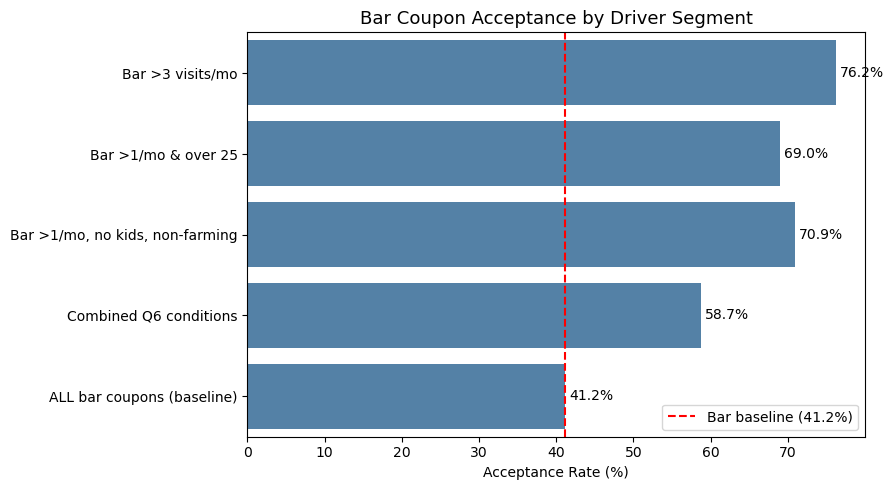


Acceptance by prior bar-visit frequency:
        mean  size
Bar               
never  18.91   788
less1  44.69   546
1~3    64.64   379
4~8    77.55   147
gt8    71.74    46


In [35]:
# Bar Q7: pull the segments together into one comparison
summary = pd.DataFrame({
    'Group': ['Bar >3 visits/mo',
              'Bar >1/mo & over 25',
              'Bar >1/mo, no kids, non-farming',
              'Combined Q6 conditions',
              'ALL bar coupons (baseline)'],
    'Acceptance': [grp_gt3['Y'].mean()*100,
                   bar_coupons[mask4]['Y'].mean()*100,
                   bar_coupons[mask5]['Y'].mean()*100,
                   bar_coupons[combined]['Y'].mean()*100,
                   bar_coupons['Y'].mean()*100]
})

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=summary, y='Group', x='Acceptance', color='steelblue')
ax.axvline(bar_coupons['Y'].mean()*100, color='red', ls='--',
           label=f"Bar baseline ({bar_coupons['Y'].mean()*100:.1f}%)")
ax.set_title('Bar Coupon Acceptance by Driver Segment', fontsize=13)
ax.set_xlabel('Acceptance Rate (%)')
ax.set_ylabel('')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Frequency is the single strongest lever -- show it directly.
freq_order = ['never', 'less1', '1~3', '4~8', 'gt8']
by_bar_freq = bar_coupons.groupby('Bar')['Y'].agg(['mean','size']).reindex(freq_order)
by_bar_freq['mean'] = (by_bar_freq['mean']*100).round(2)
print("\nAcceptance by prior bar-visit frequency:")
print(by_bar_freq)

**Hypothesis: prior bar-going habit is the dominant driver of bar-coupon acceptance.**

The pattern across every comparison above points the same direction. Drivers who
already visit bars more than three times a month accept at roughly **76%**, while
those who go three or fewer times accept at roughly **37%** — a gap of about
**39 percentage points**. No demographic variable in this dataset comes close to
that separation.

The relationship is not perfectly monotonic, however. Acceptance climbs steadily
from `never` (~19%) through `4~8` (~78%), but the highest-frequency `gt8` bucket
comes in *lower*, at ~72%. That bucket holds only ~46 bar-coupon observations, so
the dip is well within sampling noise and should not be read as a real decline.

The demographic filters in questions 4-6 look powerful, but each one contains the
frequency condition (`Bar > 1/month`). Once that condition is present, layering on
age, marital status, or passenger type moves the number by only a few points.
Condition 3 in question 6 is the tell: it is the only sub-condition that does *not*
include bar frequency, and it is by far the weakest of the three.

**Interpretation:** age and income are acting as weak proxies for an underlying
habit rather than as causes in their own right. A 45-year-old who never goes to
bars is not a good target; a 27-year-old who goes weekly is.

**Actionable takeaway:** target bar coupons on observed venue-visit behavior, not
on demographic lookalikes. Suppressing delivery to self-reported non-bar-goers
would remove a large, reliably low-converting slice of the audience.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [36]:
# Independent Investigation: Coffee House coupons
# Chosen because it is the largest coupon group in the dataset.
coffee = data[data['coupon'] == 'Coffee House'].copy()

print(f"Coffee House observations: {len(coffee):,}")
print(f"Coffee House acceptance:   {coffee['Y'].mean()*100:.2f}%")
print(f"All-coupon acceptance:     {data['Y'].mean()*100:.2f}%")

Coffee House observations: 3,809
Coffee House acceptance:   49.57%
All-coupon acceptance:     56.84%


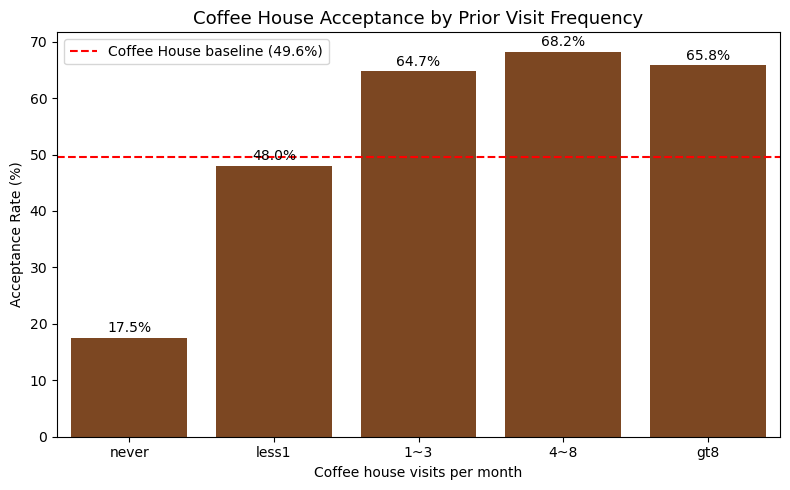

              mean  size
CoffeeHouse             
never        17.52   896
less1        47.95  1049
1~3          64.73  1015
4~8          68.24   507
gt8          65.79   342


In [37]:
# Coffee House: acceptance by prior visit frequency
freq_order = ['never', 'less1', '1~3', '4~8', 'gt8']
by_freq = coffee.groupby('CoffeeHouse')['Y'].agg(['mean','size']).reindex(freq_order)
by_freq['mean'] = by_freq['mean'] * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=by_freq.index, y=by_freq['mean'].values, color='saddlebrown')
ax.axhline(coffee['Y'].mean()*100, color='red', ls='--',
           label=f"Coffee House baseline ({coffee['Y'].mean()*100:.1f}%)")
ax.set_title('Coffee House Acceptance by Prior Visit Frequency', fontsize=13)
ax.set_xlabel('Coffee house visits per month')
ax.set_ylabel('Acceptance Rate (%)')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=2)
ax.legend()
plt.tight_layout()
plt.show()

print(by_freq.round(2))

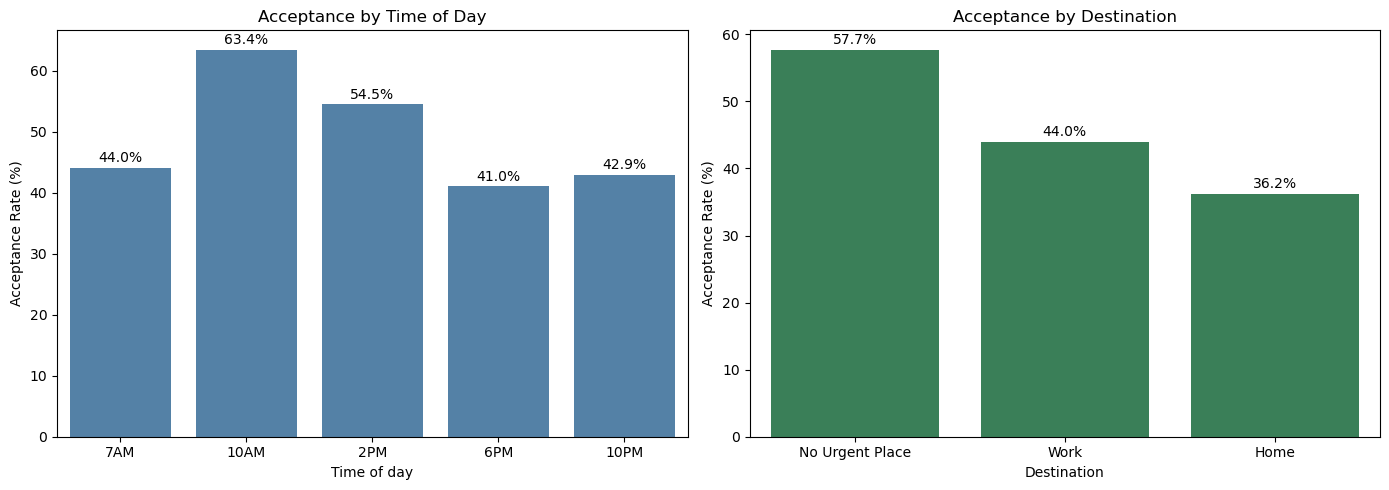

By time of day:
 time
7AM     44.00
10AM    63.43
2PM     54.49
6PM     41.04
10PM    42.91
Name: Y, dtype: float64

By destination:
 destination
No Urgent Place    57.71
Work               44.00
Home               36.23
Name: Y, dtype: float64


In [38]:
# Coffee House: time of day and destination
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

time_order = ['7AM', '10AM', '2PM', '6PM', '10PM']
by_time = coffee.groupby('time')['Y'].mean().reindex(time_order) * 100
sns.barplot(x=by_time.index, y=by_time.values, color='steelblue', ax=axes[0])
axes[0].set_title('Acceptance by Time of Day', fontsize=12)
axes[0].set_xlabel('Time of day')
axes[0].set_ylabel('Acceptance Rate (%)')
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%', padding=2)

by_dest = coffee.groupby('destination')['Y'].mean().sort_values(ascending=False) * 100
sns.barplot(x=by_dest.index, y=by_dest.values, color='seagreen', ax=axes[1])
axes[1].set_title('Acceptance by Destination', fontsize=12)
axes[1].set_xlabel('Destination')
axes[1].set_ylabel('Acceptance Rate (%)')
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%', padding=2)

plt.tight_layout()
plt.show()

print("By time of day:\n", by_time.round(2))
print("\nBy destination:\n", by_dest.round(2))

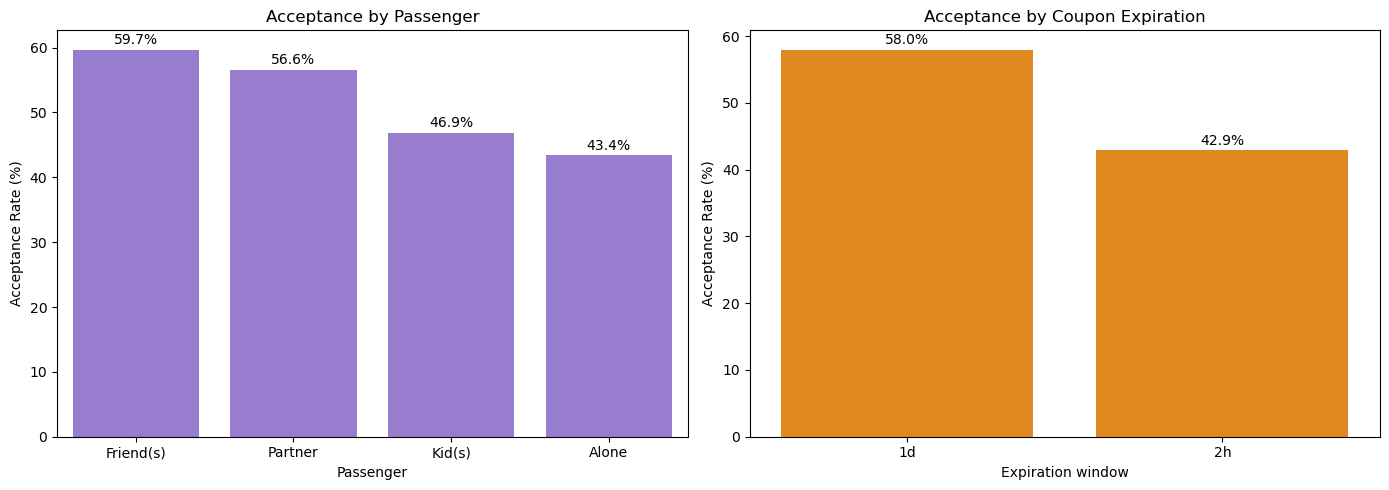

By passenger:
 passanger
Friend(s)    59.68
Partner      56.55
Kid(s)       46.88
Alone        43.36
Name: Y, dtype: float64

By expiration:
 expiration
1d    57.97
2h    42.88
Name: Y, dtype: float64


In [39]:
# Coffee House: passenger and coupon expiration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

by_pass = coffee.groupby('passanger')['Y'].mean().sort_values(ascending=False) * 100
sns.barplot(x=by_pass.index, y=by_pass.values, color='mediumpurple', ax=axes[0])
axes[0].set_title('Acceptance by Passenger', fontsize=12)
axes[0].set_xlabel('Passenger')
axes[0].set_ylabel('Acceptance Rate (%)')
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%', padding=2)

by_exp = coffee.groupby('expiration')['Y'].mean() * 100
sns.barplot(x=by_exp.index, y=by_exp.values, color='darkorange', ax=axes[1])
axes[1].set_title('Acceptance by Coupon Expiration', fontsize=12)
axes[1].set_xlabel('Expiration window')
axes[1].set_ylabel('Acceptance Rate (%)')
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%', padding=2)

plt.tight_layout()
plt.show()

print("By passenger:\n", by_pass.round(2))
print("\nBy expiration:\n", by_exp.round(2))

BEST  - regular drinker, no urgent destination, 1-day expiry:
        80.22%   (n=465)
WORST - never drinks coffee out, heading home:
        8.80%   (n=216)

Coffee House baseline: 49.57%
Spread between best and worst segment: 71.4 percentage points


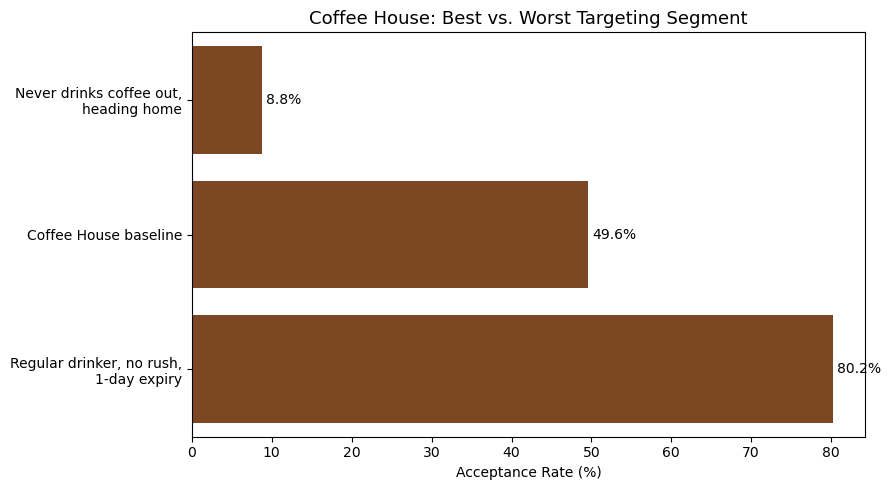

In [40]:
# Coffee House: stack the three strongest signals into one target segment
regular   = coffee['CoffeeHouse'].isin(['1~3', '4~8', 'gt8'])
no_rush   = coffee['destination'] == 'No Urgent Place'
long_exp  = coffee['expiration'] == '1d'

best  = coffee[regular & no_rush & long_exp]
worst = coffee[(coffee['CoffeeHouse'] == 'never') & (coffee['destination'] == 'Home')]

print(f"BEST  - regular drinker, no urgent destination, 1-day expiry:")
print(f"        {best['Y'].mean()*100:.2f}%   (n={len(best)})")
print(f"WORST - never drinks coffee out, heading home:")
print(f"        {worst['Y'].mean()*100:.2f}%   (n={len(worst)})")
print(f"\nCoffee House baseline: {coffee['Y'].mean()*100:.2f}%")
print(f"Spread between best and worst segment: "
      f"{(best['Y'].mean()-worst['Y'].mean())*100:.1f} percentage points")

seg = pd.DataFrame({
    'Segment': ['Never drinks coffee out,\nheading home',
                'Coffee House baseline',
                'Regular drinker, no rush,\n1-day expiry'],
    'Acceptance': [worst['Y'].mean()*100, coffee['Y'].mean()*100, best['Y'].mean()*100]
})

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=seg, y='Segment', x='Acceptance', color='saddlebrown')
ax.set_title('Coffee House: Best vs. Worst Targeting Segment', fontsize=13)
ax.set_xlabel('Acceptance Rate (%)')
ax.set_ylabel('')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

---

## Findings and Recommendations

### 1. Habit beats demographics — everywhere

The strongest predictor of whether someone accepts a coupon is whether they
already visit that kind of venue. This held for both coupon groups examined:

- **Bar coupons:** ~76% acceptance among drivers visiting bars more than 3
  times/month, vs ~37% for less frequent visitors.
- **Coffee House coupons:** ~68% acceptance among those visiting 4-8 times/month,
  vs **~18%** among those who answered `never` — the single lowest-converting
  group found anywhere in this analysis.

Age, income, marital status, and education all produced far smaller separations,
and largely disappeared once venue frequency was controlled for.

### 2. Context and timing matter, and they are actionable

Unlike demographics, context is something a delivery system controls:

- **Time of day (Coffee House):** ~64% at 10AM vs ~41% at 6PM.
- **Destination:** ~58% when headed somewhere non-urgent vs ~36% when headed home.
- **Expiration:** the 1-day window outperformed the 2-hour window by roughly
  15 percentage points.
- **Passenger:** riding with friends outperformed driving alone by ~16 points.

### 3. Coupon type sets the ceiling

Overall acceptance across all coupons was ~57%. Bar coupons landed near 41% and
Coffee House near 50%, both below that baseline — cheap restaurants and carry-out
pull the average up. Bar coupons are the hardest sell in the set.

### 4. Stacking signals produces a large spread

Combining habit and context separates the audience dramatically. Regular coffee
drinkers with no urgent destination and a 1-day expiry window accepted at a far
higher rate than people who never buy coffee out while driving home — a spread of
roughly 50 percentage points between best and worst segments.

---

### Recommendations

1. **Target on observed behavior, not demographics.** Venue-visit history is the
   highest-value targeting signal available and should take priority over age or
   income segmentation.
2. **Suppress the `never` segment.** Drivers reporting they never visit a venue
   type convert at under 20% for coffee. Withholding those sends costs almost no
   conversions and reduces notification fatigue.
3. **Send coffee coupons in the morning.** The 10AM window outperformed the 6PM
   window by more than 20 points on identical inventory.
4. **Default to the longer expiration window.** The 1-day window beat the 2-hour
   window consistently; urgency appears to suppress rather than drive acceptance.
5. **Weight toward non-urgent trips.** Drivers headed home convert worst; drivers
   with no urgent destination convert best.

### Limitations and next steps

- This is **survey data on hypothetical scenarios**, not observed redemptions.
  Stated intent typically overstates real behavior, so these rates should be read
  as relative comparisons rather than forecasts.
- All findings are **descriptive and univariate**. The variables are correlated
  (younger drivers go to bars more often), so single-variable comparisons cannot
  separate independent effects.
- **No significance testing** was performed, and some segments are small enough
  that their rates are unstable — the `gt8` bar-visit bucket contains fewer than
  50 observations, which is why its apparent dip below the `4~8` group should not
  be over-interpreted.
- **Next steps:** chi-square tests on the key comparisons, a multivariate model
  (logistic regression) to isolate independent contributions, and validation
  against real redemption data before any of this drives live targeting.